   # **Trabajo Práctico 1 (2026 - 2do semestre)**

## **1. Introducción al problema y Análisis Exploratorio**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("datatelco_customer_churn.csv")

### **Descripción del conjunto de datos y problema a resolver:**

El conjunto de datos *Telco Customer Churn* tiene información sobre 7.043 clientes de una empresa de telecomunicaciones y está compuesto por 21 variables. Cada fila representa a cada uno de los clientes, para cada uno de ellos se tienen diversas caracteristicas (columnas) que incluyen cosas como servicios contratados, modalidad de pago, antigüedad, etc.

La variable objetivo es Churn, que indica si el cliente abandonó la empresa. En el conjunto de datos, 5.174 clientes (73,46%) no abandonaron el servicio, mientras que 1.869 (26,54%) sí lo hicieron. Esta distribución muestra un desbalance entre las clases que deberá considerarse al validar el modelo y elegir las métricas de evaluación.

El objetivo del análisis en este trabajo practico es desarrollar un modelo de clasificación que permita identificar clientes con riesgo de abandonar el servicio. Esta predicción podría ayudar a la empresa a orientar acciones para retener a estos clientes (por ejemplo descuentos o promociones). Desde el punto de vista del negocio, anticipar el abandono puede reducir la pérdida de clientes.


In [2]:
# Muestra las dimensiones del dataset:
# shape[0] devuelve la cantidad de filas (clientes)
# shape[1] devuelve la cantidad de columnas (variables)
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")

# Muestra las primeras cinco filas para observar la estructura general
# del dataset y algunos ejemplos de los valores de cada variable
display(df.head())

# Muestra el tipo de dato que pandas asignó a cada columna
print("\nTipos de datos:")
display(df.dtypes.to_frame("Tipo"))

# Cuenta la cantidad de clientes pertenecientes a cada clase:
# Churn = "Yes" y Churn = "No"
print("\nDistribución de Churn:")
display(
    pd.DataFrame({

        # value_counts(normalize=True) calcula la proporción de cada clase
        # mul(100) convierte las proporciones en porcentajes
        # round(2) redondea los resultados a dos decimales
        "Cantidad": df["Churn"].value_counts(),
        "Porcentaje": df["Churn"]
            .value_counts(normalize=True)
            .mul(100)
            .round(2)
    })
)

El dataset tiene 7043 filas y 21 columnas.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Tipos de datos:


,Tipo
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object



Distribución de Churn:


,Cantidad,Porcentaje
Churn,,
No,5174,73.46
Yes,1869,26.54


### **Análisis exploratorio de datos**

El análisis exploratorio comienza con una revisión general de la calidad de los datos y de las estadísticas descriptivas de las variables numéricas. Luego estudiamos la distribución de la variable objetivo `Churn` y su relación con dos características relevantes para el problema de negocio: la antigüedad del cliente (`tenure`) y el tipo de contrato (`Contract`).

Aunque `SeniorCitizen` está almacenada mediante los valores 0 y 1, se considera una variable categórica binaria. Por otra parte, `customerID` funciona únicamente como identificador del cliente y no se incluye en el análisis descriptivo.


In [3]:
# TotalCharges ya fue convertida a numérica en el punto 2, así que acá no hace falta reconvertir
variables_numericas = ["tenure", "MonthlyCharges", "TotalCharges"]

print(f"Cantidad de clientes: {df.shape[0]}")
print(f"Cantidad de variables: {df.shape[1]}")
print("Valores faltantes en TotalCharges:", df["TotalCharges"].isna().sum())

display(df[variables_numericas].describe().round(2))


Cantidad de clientes: 7043
Cantidad de variables: 21
Valores faltantes en TotalCharges: 0


,tenure,MonthlyCharges
count,7043.00,7043.00
mean,32.37,64.76
std,24.56,30.09
min,0.00,18.25
25%,9.00,35.50
50%,29.00,70.35
75%,55.00,89.85
max,72.00,118.75


#### **Descripción general y calidad de los datos**

El dataset contiene 7043 clientes y 21 variables. Las variables numéricas consideradas son `tenure`, `MonthlyCharges` y `TotalCharges`.

La antigüedad promedio es de 32,37 meses y presenta una desviación estándar de 24,56 meses, lo que indica que el dataset contiene tanto clientes recientes como clientes de larga permanencia. El cargo mensual promedio es de 64,76, con valores comprendidos entre 18,25 y 118,75.

En `TotalCharges`, la media es de 2283,30 y la mediana de 1397,48. Esta diferencia sugiere una distribución influenciada por valores elevados. Inicialmente, la columna fue reconocida como texto debido a la presencia de registros con espacios en blanco. Estos registros se convirtieron en valores nulos para permitir el análisis numérico; su tratamiento definitivo se decidirá durante el preprocesamiento. Si esta anomalía no se detectara, la variable podría ser tratada como texto y el modelo no podría aprovechar correctamente el orden y la magnitud de sus valores.


#### **Visualización 1: distribución de la variable objetivo**

El 26,54% de los clientes abandonó el servicio, mientras que el 73,46% permaneció. Esto muestra un desbalance entre las clases, dado que los clientes que abandonaron representan aproximadamente una cuarta parte del dataset.

Este desbalance deberá considerarse durante la validación y evaluación del modelo, ya que una métrica como *accuracy* podría resultar elevada incluso si el modelo presenta dificultades para identificar a los clientes que abandonan.


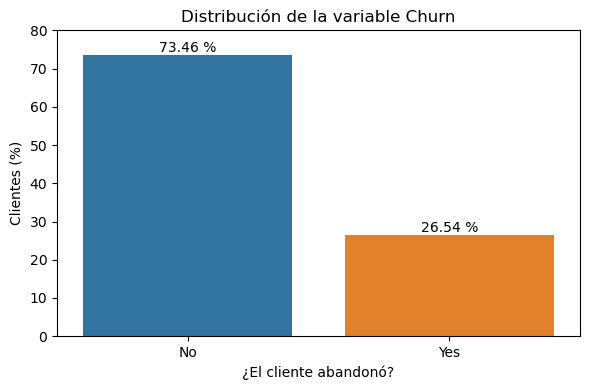

In [4]:
distribucion_churn = (
    df["Churn"]
    .value_counts()
    .rename_axis("Churn")
    .reset_index(name="Cantidad")
)

distribucion_churn["Porcentaje"] = (
    distribucion_churn["Cantidad"] / len(df) * 100
)

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=distribucion_churn,
    x="Churn",
    y="Porcentaje",
    hue="Churn",
    legend=False
)

ax.set_title("Distribución de la variable Churn")
ax.set_xlabel("¿El cliente abandonó?")
ax.set_ylabel("Clientes (%)")
ax.set_ylim(0, 80)

for barra in ax.patches:
    porcentaje = barra.get_height()
    ax.annotate(
        f"{porcentaje:.2f} %",
        (barra.get_x() + barra.get_width() / 2, porcentaje),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


#### **Visualización 2: tasa de abandono según la antigüedad**

La tasa de abandono disminuye a medida que aumenta la antigüedad. Entre los clientes con hasta 6 meses en la empresa, el 52,94% abandonó el servicio. La proporción disminuye al 35,89% entre los 7 y 12 meses, al 28,71% entre los 13 y 24 meses, al 20,39% entre los 25 y 48 meses y al 9,51% entre los 49 y 72 meses.

Esto muestra una asociación entre una menor antigüedad y una mayor tasa de abandono. Los primeros meses de la relación con el cliente podrían ser especialmente relevantes para las acciones de retención.


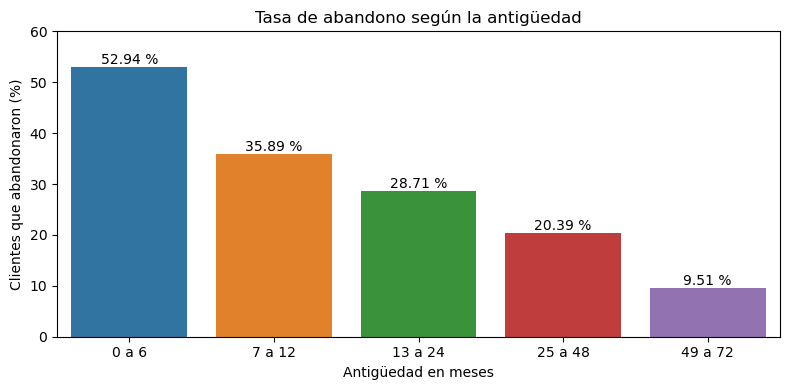

In [5]:
# Agrupamos tenure en intervalos para facilitar la interpretación
df["GrupoTenure"] = pd.cut(
    df["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=["0 a 6", "7 a 12", "13 a 24", "25 a 48", "49 a 72"]
)

tasa_tenure = (
    pd.crosstab(
        df["GrupoTenure"],
        df["Churn"],
        normalize="index"
    )["Yes"]
    .mul(100)
    .reset_index(name="Tasa de abandono")
)

plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=tasa_tenure,
    x="GrupoTenure",
    y="Tasa de abandono",
    hue="GrupoTenure",
    legend=False
)

ax.set_title("Tasa de abandono según la antigüedad")
ax.set_xlabel("Antigüedad en meses")
ax.set_ylabel("Clientes que abandonaron (%)")
ax.set_ylim(0, 60)

for barra in ax.patches:
    porcentaje = barra.get_height()
    ax.annotate(
        f"{porcentaje:.2f} %",
        (barra.get_x() + barra.get_width() / 2, porcentaje),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


#### **Visualización 3: tasa de abandono según el tipo de contrato**

La tasa de abandono presenta diferencias importantes según el tipo de contrato. Entre los clientes con contrato mensual, el 42,71% abandonó el servicio. Esta proporción disminuye al 11,27% para los contratos de un año y al 2,83 % para los contratos de dos años.

Por lo tanto, los clientes con contratos de mayor duración presentan una tasa de abandono considerablemente menor. El tipo de contrato parece contener información relevante para anticipar el abandono.


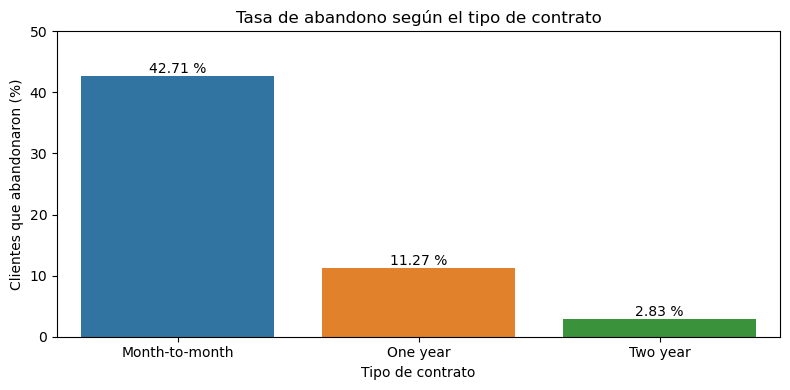

In [6]:
tasa_contrato = (
    pd.crosstab(
        df["Contract"],
        df["Churn"],
        normalize="index"
    )["Yes"]
    .mul(100)
    .sort_values(ascending=False)
    .reset_index(name="Tasa de abandono")
)

plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=tasa_contrato,
    x="Contract",
    y="Tasa de abandono",
    hue="Contract",
    legend=False
)

ax.set_title("Tasa de abandono según el tipo de contrato")
ax.set_xlabel("Tipo de contrato")
ax.set_ylabel("Clientes que abandonaron (%)")
ax.set_ylim(0, 50)

for barra in ax.patches:
    porcentaje = barra.get_height()
    ax.annotate(
        f"{porcentaje:.2f} %",
        (barra.get_x() + barra.get_width() / 2, porcentaje),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


#### **Principales hallazgos**

El análisis exploratorio muestra que la variable objetivo está desbalanceada y que la tasa de abandono se relaciona claramente con la antigüedad y el tipo de contrato. Los clientes recientes y aquellos con contratos mensuales presentan las mayores tasas de abandono.

Estas relaciones sugieren que `tenure` y `Contract` podrían aportar información útil al modelo predictivo. Sin embargo, las asociaciones observadas no demuestran que estas variables sean por sí mismas la causa del abandono.


In [7]:
import pandas as pd

df = pd.read_csv("datatelco_customer_churn.csv")

pd.to_numeric(df['TotalCharges'], errors='coerce')
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### **Problema con las columnas que no son reconocidas directamente como numéricas**

Luego de investigar un poco, descubrimos que Pandas infiere el dtype al leer el CSV, columna por columna, y aplica una regla simple: si todos los valores de la columna se pueden convertir a número, la hace numérica pero si aparece aunque sea uno solo que no puede, toda la columna cae a object. Object significa que la columna no guarda los valores en sí, sino punteros a objetos de Python. En la práctica, casi siempre son strings.

El caso que encontramos fue con TotalCharges. Hay 7043 filas, de las cuales 7032 son montos perfectamente numéricos. Pero 11 tienen un espacio en blanco. Ese espacio no se puede convertir a número, así que pandas se rinde y guarda las 7043 como strings. Un "29.85" con comillas, no un 29.85.

Los espacios en blanco aparecen cuando son clientes con tenure = 0, o sea que recién se dieron de alta y todavía no facturaron nada. Esa columna sí es numérica conceptualmente, pero pandas la lee como object porque hay unas 11 filas con un string vacío (" ") en lugar de un número.

El impacto de no detectarlo es que la columna queda como texto y el modelo o la ignora, o si alguien la codifica como categórica, termina tratando cada monto como una categoría distinta.

Se arregla con pd.to_numeric(df['TotalCharges'], errors='coerce') y después tendríamos que decidir qué hacer con esos NaN (imputar con 0 tiene sentido acá, justificando que no facturaron todavía).

In [8]:
# convertimos los " " no parseables a NaN
print(f"\nDtype de TotalCharges antes : {df['TotalCharges'].dtype}")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# verificamos nuestro diagnóstico
faltantes = df['TotalCharges'].isna()
print(f"Filas con TotalCharges nulo: {faltantes.sum()}")
print(f"Valores de tenure en esas filas: {df.loc[faltantes, 'tenure'].unique()}")

# acá hacemos un chequeo final
print(f"\nDtype de TotalCharges ahora: {df['TotalCharges'].dtype}")
print(f"Nulos restantes: {df['TotalCharges'].isna().sum()}")


Dtype de TotalCharges antes : object
Filas con TotalCharges nulo: 11
Valores de tenure en esas filas: [0]

Dtype de TotalCharges ahora: float64
Nulos restantes: 11


## **2. Preprocesamiento y prevención de Data Leakage**

### **Valores faltantes**

Compruebo que el único problema de datos faltantes en todo el dataset fue el de TotalCharges, lo cual se deja constancia a continuación.

In [9]:
# Veo cuantos valores "nulos" hay, y en qué columnas
print(df.isnull().sum()[df.isnull().sum() > 0])

# Hago chequeo de nulos "disfrazados", es decir, strings vacíos o con espacios en columnas categóricas
for col in df.select_dtypes(include='object').columns:
    valores_raros = df[col].apply(lambda x: isinstance(x, str) and x.strip() == '').sum()
    if valores_raros > 0:
        print(f"{col}: {valores_raros} valores vacíos/espacios")

if not any(df[col].apply(lambda x: isinstance(x, str) and x.strip() == '').sum() > 0 
           for col in df.select_dtypes(include='object').columns):
    print("No se encontraron valores vacíos/espacios ocultos en columnas categóricas.")

TotalCharges    11
dtype: int64
No se encontraron valores vacíos/espacios ocultos en columnas categóricas.


Para las filas que tienen `TotalCharges` nulo y `tenure=0`, imputo su `TotalCharges` con 0, ya que son clientes que recién se dieron de alta y todavía no generaron ganancias para la empresa.

Si quedaran filas con `TotalCharges` nulo y `tenure>0`, esos casos se imputarían luego del split de datos, para evitar data leakage (desarrollamos esta justificación en detalle más abajo, en el inciso sobre el orden de las operaciones). Como vemos a continuación, con este dataset no ocurre este caso.

In [10]:
# Imputación de los datos para cada caso
condicion_tenure_cero = (df['TotalCharges'].isna()) & (df['tenure'] == 0)
condicion_otros_nulos = (df['TotalCharges'].isna()) & (df['tenure'] != 0)

print(f"Nulos con tenure = 0: {condicion_tenure_cero.sum()}")
print(f"Nulos con tenure > 0: {condicion_otros_nulos.sum()}")

df.loc[condicion_tenure_cero, 'TotalCharges'] = 0

print(f"Nulos restantes en TotalCharges: {df['TotalCharges'].isna().sum()}")

Nulos con tenure = 0: 11
Nulos con tenure > 0: 0
Nulos restantes en TotalCharges: 0


In [11]:
# Imputación para el caso tenure=0: TotalCharges = 0 (lógica de negocio: el cliente todavía no facturó nada)
df.loc[condicion_tenure_cero, 'TotalCharges'] = 0

# Chequeo si quedan nulos por resolver
print(f"Nulos restantes en TotalCharges: {df['TotalCharges'].isna().sum()}")

Nulos restantes en TotalCharges: 0


### **Variables categóricas**

Al revisar las categorías de las variables de texto, encontramos que varias columnas no son binarias en apariencia, pero sí lo son en esencia:

- `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`,`StreamingMovies` tienen 3 valores: `Yes`, `No`, `No internet service`.
- `MultipleLines` tiene 3 valores: `Yes`, `No`, `No phone service`.

El problema es que las categorías `No internet service` y `No phone service` no aportan información nueva. Por ejemplo, un cliente tiene `"No internet service"` en esas 6 columnas si y solo si `InternetService == "No"`, y tiene `"No phone service"` en `MultipleLines` si y solo si `PhoneService == "No"`. En síntesis, esas categorías son redundantes con una categoría que ya está en el dataset.

Por eso, decidimos colapsar `"No internet service"` y `"No phone service"` en `"No"`. Esto convierte a las 7 columnas mencionadas en binarias, permitiendo aplicar Label Encoding de forma consistente con el resto de las variables Yes/No, y sin perder información (porque ya está en `InternetService` y `PhoneService`).

In [12]:
# Colapsamos "No internet service" / "No phone service" en "No"
cols_no_internet = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in cols_no_internet:
    df[col] = df[col].replace('No internet service', 'No')

df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

# Verificación
for col in cols_no_internet + ['MultipleLines']:
    print(f"{col}: {df[col].unique()}")

OnlineSecurity: ['No' 'Yes']
OnlineBackup: ['Yes' 'No']
DeviceProtection: ['No' 'Yes']
TechSupport: ['No' 'Yes']
StreamingTV: ['No' 'Yes']
StreamingMovies: ['No' 'Yes']
MultipleLines: ['No' 'Yes']


Ahora aplicamos:

* **One Hot Encoding** a 'InternetService', 'Contract' y 'PaymentMethod' 
* **Label Encoding** a 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies' y 'PaperlessBilling'.

A continuación explicamos por qué elegimos cada método para esos features:

**Label Encoding** asigna un número entero a cada categoría (en nuestro caso, `No → 0`, `Yes → 1`). El problema es que, al ser números, el modelo asume que existe una distancia
uniforme y un orden entre las categorías (que "2" está más lejos de "0" que "1", por ejemplo), aunque las categorías originales sean simplemente etiquetas sin ningún orden real.
Con **2 categorías** esto no genera ningún problema, ya que existe un único salto posible (de 0 a 1), así que no hay ninguna relación de orden o distancia intermedia que el modelo pueda interpretar mal. Así, usamos Label Encoding en las 12 columnas binarias.

**One-Hot Encoding** lo reservamos para las columnas con **3 o más categorías sin orden natural** (`InternetService`, `Contract`, `PaymentMethod`). Para estos casos creemos que sería un error usar Label Encoding, porque el modelo terminaría asumiendo una relación de orden y distancia entre las categorías que no existe en realidad. One-Hot Encoding evita ese problema, ya que crea una columna binaria independiente por cada categoría, sin imponer ningún orden ni distancia entre ellas.

Usamos `drop_first=True` en todos los casos. Al codificar una variable con One-Hot Encoding, alcanza con dejar todas las categorías menos una para representarla sin ambigüedad; si una fila da 0 en todas las columnas generadas, ya se sabe que pertenece a la categoría restante (la que no se generó columna). Si en cambio generáramos una columna por cada categoría sin excepción, la última quedaría totalmente determinada por el resto, lo que puede hacer que el ajuste de la Regresión Logística se vuelva inestable.

In [13]:
# Ahora aplico One Hot Encoding y Label Encoding a las columnas categóricas
from sklearn.preprocessing import LabelEncoder

# customerID es un identificador único por cliente, no una variable predictiva. Si no hacemos este paso, el One-Hot Encoding lo trataría como una columna categórica
df = df.drop(columns=['customerID'])

# Separamos las columnas categóricas en binarias (2 categorías) y multiclase (3+), dejando Churn afuera porque es el target y lo tratamos aparte
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('Churn')

binarias = [col for col in cat_cols if df[col].nunique() == 2]
multiclase = [col for col in cat_cols if df[col].nunique() > 2]

# Verificamos
print("Binarias (Label Encoding):", binarias)
print("Multiclase (One-Hot Encoding):", multiclase)

Binarias (Label Encoding): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling']
Multiclase (One-Hot Encoding): ['InternetService', 'Contract', 'PaymentMethod']


In [14]:
# Label Encoding para las binarias:
le = LabelEncoder()
mapeos = {}

for col in binarias:
    df[col] = le.fit_transform(df[col])
    mapeos[col] = dict(zip(le.classes_, le.transform(le.classes_)))

for col, mapeo in mapeos.items():
    print(f"{col}: {mapeo}")

# One-Hot Encoding para las que tienen 3 o más categorías 
df = pd.get_dummies(df, columns=multiclase, drop_first=True)

# Encodeamos el target por separado (No -> 0, Yes -> 1)
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

# Chequeo final
print(df.dtypes.value_counts())
print(df.select_dtypes(include='object').columns)

# Convertimos columnas booleanas a enteros para mejor compatibilidad con modelos de ML
dummy_cols = df.select_dtypes(include='bool').columns
df[dummy_cols] = df[dummy_cols].astype(int)

gender: {'Female': np.int64(0), 'Male': np.int64(1)}
Partner: {'No': np.int64(0), 'Yes': np.int64(1)}
Dependents: {'No': np.int64(0), 'Yes': np.int64(1)}
PhoneService: {'No': np.int64(0), 'Yes': np.int64(1)}
MultipleLines: {'No': np.int64(0), 'Yes': np.int64(1)}
OnlineSecurity: {'No': np.int64(0), 'Yes': np.int64(1)}
OnlineBackup: {'No': np.int64(0), 'Yes': np.int64(1)}
DeviceProtection: {'No': np.int64(0), 'Yes': np.int64(1)}
TechSupport: {'No': np.int64(0), 'Yes': np.int64(1)}
StreamingTV: {'No': np.int64(0), 'Yes': np.int64(1)}
StreamingMovies: {'No': np.int64(0), 'Yes': np.int64(1)}
PaperlessBilling: {'No': np.int64(0), 'Yes': np.int64(1)}
int64      15
bool        7
float64     2
Name: count, dtype: int64
Index([], dtype='object')


### **Orden de las operaciones: Train/Test Split antes del escalado y la imputación**

Primero se separan los datos en entrenamiento y testeo, y luego se realiza el escalado, calculado únicamente con X_train y aplicado después a X_test sin volver a fitearlo allí.

En nuestro notebook, esto se ve concretamente en el escalado: hicimos el `train_test_split` antes de aplicar `StandardScaler`, fiteamos el scaler (`fit_transform`) únicamente sobre `X_train`, y al conjunto de test le aplicamos solamente `transform`, usando la media y el
desvío ya calculados en train.  

A diferencia del escalado, en este dataset la imputación de TotalCharges se resolvió con una regla de negocio (clientes con tenure = 0 no facturaron nada, por lo tanto TotalCharges = 0), que no depende de ninguna estadística calculada sobre los datos. Por eso la aplicamos sobre el dataset completo, antes del split, sin que esto genere Data Leakage (ver justificación en la sección de Valores Faltantes).

Si se hiciera la división de los datos en el orden incorrecto, es decir, si se calculara la media y el desvío del `StandardScaler` sobre el dataset completo (train + test juntos) antes de separarlos, esa media y desvío quedarían "contaminadas" con información del test set. El modelo se entrenaría sobre datos escalados con una referencia que incluye información que, en un escenario real, no debería estar disponible en el momento de entrenar; el conjunto de test se supone que representa datos "nuevos" que el modelo nunca vio, y esa premisa se rompe si sus valores influyeron aunque sea indirectamente en cómo se transformó el train.

Esto es un caso de Data Leakage, ya que el conjunto de test deja de ser información completamente "nueva" para el modelo, porque participó indirectamente en el cálculo del desvío y media usadas para transformar el train. Esto rompe el supuesto central de que el test simule datos no vistos, y hace que la métrica de test deje de ser una estimación confiable del desempeño real del modelo.

## **3. Estrategia de Validación**

Vamos a hacer el Split del dataset en un 80% de datos para que vayan a train y un 20% para que vayan a Test. Con el random_state=42, las filas que caen en train y test son
exactamente las mismas de antes (misma partición, reproducible). Como ahora todas las features son numéricas podemos dejar todo listo para que luego escalemos ciertas columnas. Usamos stratify=y porque estratifica, es decir, mantiene la misma proporción de "se va / no se va" en train y en test. Como vimos en el punto 1, las clases están desbalanceadas, por eso importa.

In [15]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Churn'])   # todas las features (ya numéricas), sin escalar
y = df['Churn']                  # el target: 0 = no se va, 1 = se va

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y )

### **Armamos el preprocesador (el escalado por columnas)**

Las columnas numéricas que sí hay que escalar son "tenure", "MonthlyCharges" y "TotalCharges". Usamos StandardScaler para transformarlas. El resto (binarias) pasan sin cambios gracias a remainder='passthrough'.

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

cols_numericas = ['tenure', 'MonthlyCharges', 'TotalCharges']

preprocesador = ColumnTransformer(
    transformers=[('escalado', StandardScaler(), cols_numericas)],
    remainder='passthrough'
)

### **Acá armamos el Pipeline completo (preprocesado + modelo)**

Al llegar a la validación cruzada nos topamos con un problema: el escalado tiene que ajustarse dentro de cada fold (usando solo los datos de entrenamiento de esa ronda) para no filtrar información. Hacerlo a mano implicaba reescribir el fit/transform del scaler en cada iteración, con el riesgo de equivocarnos y reintroducir data leakage sin darnos cuenta.

La solución fue el Pipeline: un objeto que encadena el preprocesamiento y el modelo, y los trata como una sola unidad. Le definimos dos pasos en orden. Primero el ColumnTransformer que escala las variables numéricas, después la LogisticRegression. A partir de ahí el pipeline se comporta como si fuera un único modelo.

La gran ventaja es que cuando el K-Fold (o el fit final del 4to punto del TP) recibe datos, el pipeline aplica todos sus pasos usando únicamente esas filas. Es decir, el escalado se reajusta solo con el train de cada ronda de forma automática, sin que tengamos que programar el loop nosotros. En una sola llamada obtenemos preprocesamiento + modelado, con la garantía de que no hay fuga de información entre folds.

Usamos Regresión logística pero le pusimos valor = 1000 a max_iter por recomendaciones de Claude. El valor por defecto (100) a veces no alcanza y genera un warning, subirlo le da margen para terminar sin afectar el resultado.

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('modelo', LogisticRegression(max_iter=1000, random_state=42))
])

### **Definimos el esquema de K-Fold estratificado**

Usamos StratifiedKFold, que es la versión de K-Fold que mantiene la proporción de clases en cada fold. Como el Churn está desbalanceado, es la correcta. Escribimos también: n_splits=5 por los 5 folds que pide el TP.

Pusimos shuffle=True por recomendación de Claude para barajar las filas antes de cortar. Es decir, desordenamos las filas al azar antes de cortarlas en folds. Sin esto, cortaría los folds en el orden en que vienen las filas, y si el dataset tuviera algún orden oculto, los folds saldrían sesgados. 

In [18]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### **Ejecutamos la validación cruzada**

Acá es donde por fin corre todo. Usamos una función que hace el loop de las 5 rondas (una por fold).

Con `skf.split(X_train, y_train)` generamos las 5 pasadas. `skf` (nuestro StratifiedKFold) tiene un método `.split()` que, cuando lo recorremos con un for, nos va entregando 5 pares de listas, uno por ronda: `indices_train` tiene los números de fila que van a entrenar en esta ronda (los 4 folds) e `indices_val` los números de fila que van a validar en esta ronda (el fold reservado).

Es decir que `skf.split()` no nos da los datos, nos da las posiciones: "en la ronda 1, entrenamos con estas filas y validamos con estas otras". Y como es un StratifiedKFold, esas listas ya vienen armadas respetando el balance de clases y el barajado. El for simplemente las recorre una tras otra, y por eso da exactamente 5 vueltas: hay 5 pares.

`.iloc[indices_train]`: iloc selecciona filas por su posición. Con la lista de índices que nos dio `.split()`, agarramos justo las filas de esa ronda. Así construimos el "train de la ronda n" y la "validación de la ronda n".

Con `pipeline.fit(X_fold_train, y_fold_train)` entrenamos el pipeline entero (escalado + modelo) usando solo los 4 folds y `pipeline.predict(X_fold_val)` predice sobre el fold reservado. 

A lo último guardamos con `.append(...)` el resultado de esta ronda en la lista para promediar al final.

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# acá vamos a ir guardando la métrica de cada ronda
resultados_por_fold = []

numero_de_ronda = 1

# skf.split(..) nos da, para cada una de las 5 rondas, qué filas entrenan y cuáles validan
for indices_train, indices_val in skf.split(X_train, y_train):
    
    X_fold_train = X_train.iloc[indices_train]
    y_fold_train = y_train.iloc[indices_train]
    X_fold_val   = X_train.iloc[indices_val]
    y_fold_val   = y_train.iloc[indices_val]

    pipeline.fit(X_fold_train, y_fold_train)

    y_fold_pred = pipeline.predict(X_fold_val)

    acc  = accuracy_score(y_fold_val, y_fold_pred)
    prec = precision_score(y_fold_val, y_fold_pred)
    rec  = recall_score(y_fold_val, y_fold_pred)
    f1   = f1_score(y_fold_val, y_fold_pred)

    resultados_por_fold.append({'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1})

    print(f"Ronda {numero_de_ronda}: accuracy={acc:.4f}  precision={prec:.4f}  recall={rec:.4f}  f1={f1:.4f}")
    numero_de_ronda += 1

Ronda 1: accuracy=0.7986  precision=0.6452  recall=0.5351  f1=0.5850
Ronda 2: accuracy=0.7817  precision=0.6073  recall=0.5017  f1=0.5495
Ronda 3: accuracy=0.8021  precision=0.6583  recall=0.5284  f1=0.5863
Ronda 4: accuracy=0.8172  precision=0.6667  recall=0.6221  f1=0.6436
Ronda 5: accuracy=0.8126  precision=0.6930  recall=0.5284  f1=0.5996


### **Resumimos: promedio y desvío por métrica**

* valores.mean(): el promedio de los 5 folds → tu estimación de qué tan bien generaliza.
* valores.std(): el desvío estándar → qué tan parejo fue entre folds. Chico = estable; grande = sensible a la partición.
* El :.4f es solo formato (4 decimales).

In [20]:
import pandas as pd

tabla = pd.DataFrame(resultados_por_fold)

tabla.index = [f"Ronda {i+1}" for i in range(len(tabla))]

print("Métrica por ronda:")
print(tabla.round(4))

print("\nPromedio de cada métrica (los 5 folds):")
print(tabla.mean().round(4))

print("\nDesvío estándar de cada métrica:")
print(tabla.std().round(4))

Métrica por ronda:
         accuracy  precision  recall      f1
Ronda 1    0.7986     0.6452  0.5351  0.5850
Ronda 2    0.7817     0.6073  0.5017  0.5495
Ronda 3    0.8021     0.6583  0.5284  0.5863
Ronda 4    0.8172     0.6667  0.6221  0.6436
Ronda 5    0.8126     0.6930  0.5284  0.5996

Promedio de cada métrica (los 5 folds):
accuracy     0.8025
precision    0.6541
recall       0.5431
f1           0.5928
dtype: float64

Desvío estándar de cada métrica:
accuracy     0.0138
precision    0.0315
recall       0.0460
f1           0.0339
dtype: float64


**Por qué K-Fold en vez de un simple Holdout** : El problema es que nuestra estimación depende de qué filas cayeron en ese Holdout", hay que tener suerte de que los datos hayan sigo los suficiente heterogeneos para abarcar todas las posibles predicciones que hagamos. K-Fold usa todas las filas para validar (cada una una vez, a lo largo de las 5 rondas) y promedia, dando una estimación más robusta y menos dependiente del azar. Además, al reportar el desvío, vimos cuán estable es el modelo que armamos.

**Por qué Stratified K-Fold**: sabemos que el Churn está desbalanceado (bastante más No que Si). Con un K-Fold común, por azar un fold podría quedar con muy pocos Sí, y su validación sería poco representativa. Estratificar fuerza a que cada fold tenga la misma proporción de clases que el total, así cada ronda evalúa sobre una muestra representativa.

## **4. Evaluación del modelo base**
Entrenamos el pipeline completo (escalado + Regresión Logística) sobre **todo** el conjunto de entrenamiento (`X_train`, las mismas ~5634 filas usadas en el K-Fold, pero ahora sin partirlas en folds), y lo evaluamos una única vez sobre el conjunto de testeo (`X_test`), que el modelo no vio en ningún momento del proceso anterior.

In [21]:
# Entrenamos el pipeline (preprocesamiento + modelo) sobre TODO el train set Y Predecimos sobre el test set (el pipeline aplica el mismo escalado fiteado en train)
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

Accuracy : 0.8055
Precision: 0.6582
Recall   : 0.5561
F1-Score : 0.6029


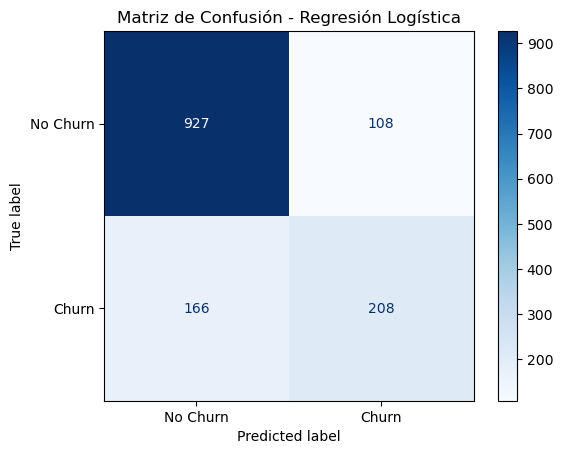

In [22]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusión - Regresión Logística')
plt.show()

### **Si creáramos un modelo naive que siempre prediga la clase mayoritaria, ¿qué Accuracy tendrÍa?**

In [23]:
# Modelo naive: predice siempre la clase mayoritaria en el train set
clase_mayoritaria = y_train.mode()[0]
y_pred_naive = [clase_mayoritaria] * len(y_test)

acc_naive = accuracy_score(y_test, y_pred_naive)
print(f"Distribución de clases en test: {y_test.value_counts(normalize=True).to_dict()}")
print(f"Accuracy del modelo naive (predice siempre '{clase_mayoritaria}'): {acc_naive:.4f}")

Distribución de clases en test: {0: 0.7345635202271115, 1: 0.2654364797728886}
Accuracy del modelo naive (predice siempre '0'): 0.7346


### **¿Es el Accuracy una buena métrica para este problema?**

El dataset está desbalanceado: aproximadamente 73.5% de los clientes no se da de baja (`Churn = No`) contra 26.5% que sí (`Churn = Yes`). Esto significa que un modelo "naive" que
prediga siempre la clase mayoritaria (`No`), sin aprender absolutamente nada del problema, obtiene un Accuracy de aproximadamente 73.5%, muy cercano al Accuracy real de nuestro modelo de Regresión Logística.

Esto deja en evidencia que el Accuracy **no es una buena métrica por sí sola** para este problema: un número alto de Accuracy puede estar ocultando que el modelo es malo prediciendo la clase minoritaria (`Churn = Yes`), que es justamente la clase que le interesa a la empresa para poder actuar (ofrecer descuentos, retener clientes, etc.). Un modelo que "acierta mucho" en términos globales puede seguir siendo inútil desde el punto de vista de negocio si falla sistemáticamente en detectar a los clientes que realmente se van a ir.

Por eso, en este contexto conviene mirar Precision, Recall y F1-Score específicamente sobre la clase `Churn = Yes` (que es la clase positiva/minoritaria), y no solo el Accuracy general. La matriz de confusión también es clave: nos permite ver cuántos verdaderos positivos (clientes que se iban y el modelo detectó) versus falsos negativos (clientes que se iban y el modelo no detectó) hay, algo que el Accuracy por sí solo no distingue.

## **5. Análisis de Negocio e Impacto de las Métricas**

### **Segundo modelo: Regresión Logística + SMOTE**

Para este punto, entrenamos un segundo modelo aplicando una técnica de balanceo de clases, y volvemos a calcular las mismas métricas que en el punto 4, para poder comparar ambos modelos de forma directa.

Usamos el mismo modelo que en el punto anterior a propósito, en vez de probar un algoritmo distinto. Si cambiáramos de modelo no podríamos saber si una diferencia en las métricas viene del balanceo o del cambio de algoritmo, así que mantener el modelo fijo nos ayuda a aislar la variable que realmente nos interesa comparar, lo cual en este caso es disminuir los efectos negativos del balanceo de clases.

Elegimos oversampling ya que nuestro dataset tiene un desbalance moderado (73.5% No-Churn vs. 26.5% Churn), y el conjunto de entrenamiento no es muy grande (aproximadamente 5634 filas). Aplicar Undersampling significaría descartar una porción grande de la clase mayoritaria (No-Churn) hasta emparejarla con la minoritaria, perdiendo información real que el modelo podría aprovechar. Oversampling, en cambio, aumenta la clase minoritaria sin tirar datos existentes, aprovechando todo lo que ya tenemos.

Además, elegimos SMOTE como técnica de oversampling. Esto debido a que el oversampling aleatorio más básico duplica filas existentes de la clase minoritaria hasta emparejar las proporciones; el problema es que, al repetir exactamente los mismos puntos varias veces, el modelo puede
sobreajustarse a esos casos particulares en vez de aprender un patrón general. SMOTE evita esto, ya que en lugar de duplicar, genera puntos sintéticos nuevos interpolando entre un ejemplo de la clase minoritaria y sus vecinos más cercanos (también de la clase minoritaria), en el
espacio de las features. Esto le da al modelo más variedad para aprender la región de la clase minoritaria, en vez de memorizar los mismos puntos repetidos.

In [24]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Mismo preprocesador (escalado) que usamos antes, mismo modelo (Regresión Logística)
pipeline_smote = ImbPipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('smote', SMOTE(random_state=42)),
    ('modelo', LogisticRegression(max_iter=1000, random_state=42))
])

# Entrenamos sobre todo el train set (SMOTE actúa acá, generando muestras sintéticas de la clase minoritaria solo dentro del entrenamiento)
pipeline_smote.fit(X_train, y_train)

# Predecimos sobre test SIN SMOTE (el pipeline sabe que en predict no se aplica SMOTE, solo el escalado + el modelo ya entrenado). Test mantiene su desbalance real.
y_pred_smote = pipeline_smote.predict(X_test)

Accuracy : 0.7374
Precision: 0.5034
Recall   : 0.7968
F1-Score : 0.6170


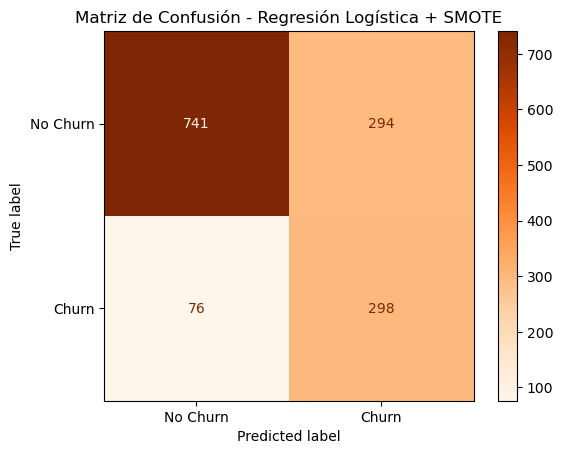

In [25]:
#Calculamos las métricas para este modelo.
cm_smote = confusion_matrix(y_test, y_pred_smote)

acc_smote = accuracy_score(y_test, y_pred_smote)
prec_smote = precision_score(y_test, y_pred_smote)
rec_smote = recall_score(y_test, y_pred_smote)
f1_smote = f1_score(y_test, y_pred_smote)

print(f"Accuracy : {acc_smote:.4f}")
print(f"Precision: {prec_smote:.4f}")
print(f"Recall   : {rec_smote:.4f}")
print(f"F1-Score : {f1_smote:.4f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm_smote, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Oranges', values_format='d')
plt.title('Matriz de Confusión - Regresión Logística + SMOTE')
plt.show()

### **Análisis de negocio**
1. Un falso positivo (es decir, el modelo predice que un cliente se irá pero en realidad no lo hace) tiene un efecto negativo sobre la empresa. Le está dando un descuento a un cliente que no se irá, por lo que está perdiendo dinero.  

2. Un falso negativo (el modelo predice que un cliente no se irá, cuando en realidad sí lo hace) también tiene un efecto negativo, y en general es el más costoso comparado al falso positivo, ya que la empresa pierde por completo los ingresos futuros de ese cliente, sin haber tenido ninguna oportunidad de intervenir a tiempo. Es un supuesto razonable en la industria de telecomunicaciones que adquirir un cliente nuevo suele costar más que retener uno existente, lo cual refuerza que el costo de un Falso Negativo (perder al cliente del todo) suele superar al de un Falso Positivo (dar un descuento innecesario).  

3. Si el descuento ofrecido es muy costoso para la empresa, conviene maximizar Precision. Cada Falso Positivo (ofrecerle el descuento a alguien que no se iba a ir) implica un gasto innecesario, así que en ese escenario es preferible que el modelo sea más selectivo y solo prediga "se va a ir" cuando tiene alta confianza, aunque eso signifique más Falsos Negativos.

    Si en cambio el descuento fuera casi gratuito, convendría maximizar Recall. El costo de un Falso Positivo sería insignificante, así que conviene intentar no dejar ir a aquellos clientes que están pensando hacerlo, aunque eso implique "desperdiciar" descuentos en algunos clientes que de todas formas no se iban a ir.

    Comparando nuestras dos matrices de confusión, el modelo sin SMOTE tuvo mayor Precision y menor Recall que el modelo con SMOTE (que sacrifica algo de Precision a cambio de más Recall). Con esto, si el descuento es caro, el modelo del punto 4 (sin aplicar técnicas de Oversampling) es más conveniente, y si el descuento es barato, el modelo con SMOTE es más conveniente.

## **Parte II**

### **Elección y definición del nuevo target**

Para reformular el problema elegimos la variable `tenure`, que representa la antigüedad del cliente en meses. Como se trata de una variable numérica, fue necesario transformarla en una variable categórica binaria denominada `tenure_establecido`. La nueva variable objetivo se define como:

- `0`: **cliente nuevo**, con una antigüedad menor o igual a un año (tenure_establecido <= 12).
- `1`: **cliente establecido**, con una antigüedad mayor a 12 meses (tenure_establecido > 12).

Se eligió el umbral de 12 meses porque representa el primer año de relación del cliente con la empresa lo cual es interpretable desde la perspectiva del negocio. Superar ese período puede considerarse una señal de que el cliente está establecido, mientras que los clientes que todavía se encuentran dentro de su primer año no lo estan y por lo tanto tienen mas riesgo de dejar el servicio. 

El nuevo problema consiste en predecir si un cliente es nuevo o establecido a partir del resto de caracteristicas. La columna original `tenure` fue excluida de las variables predictoras porque fue utilizada para construir el nuevo target y por lo tanto conservarla produciría data leakage.

In [26]:
# Nuevo target: tenure_establecido (1 = cliente establecido > 12 meses, 0 = cliente nuevo)
df['tenure_establecido'] = (df['tenure'] > 12).astype(int)

# Vemos cuál es la proporción de clientes establecidos y nuevos en el dataset
print(df['tenure_establecido'].value_counts(normalize=True))

# Eliminamos tenure (ahora redundante con el target), Churn (para para separar el nuevo problema del original) y TotalCharges (para evitar multicolinealidad con tenure) 
X_p2 = df.drop(columns=['tenure', 'tenure_establecido', 'Churn', 'TotalCharges'])
y_p2 = df['tenure_establecido']

X_train_p2, X_test_p2, y_train_p2, y_test_p2 = train_test_split(
    X_p2, y_p2, test_size=0.2, random_state=42, stratify=y_p2
)

tenure_establecido
1    0.689621
0    0.310379
Name: proportion, dtype: float64


In [27]:
# Ya no escalamos 'tenure' (es el target ahora) ni 'TotalCharges' (redundante con 'tenure'), solo las numéricas que quedan
cols_numericas_p2 = ['MonthlyCharges']

preprocesador_p2 = ColumnTransformer(
    transformers=[('escalado', StandardScaler(), cols_numericas_p2)],
    remainder='passthrough'
)

# Modelo simple, out-of-the-box
pipeline_p2 = Pipeline(steps=[
    ('preprocesamiento', preprocesador_p2),
    ('modelo', LogisticRegression(max_iter=1000, random_state=42))
])

pipeline_p2.fit(X_train_p2, y_train_p2)
y_pred_p2 = pipeline_p2.predict(X_test_p2)

Accuracy : 0.8254
Precision: 0.8652
Recall   : 0.8848
F1-Score : 0.8749


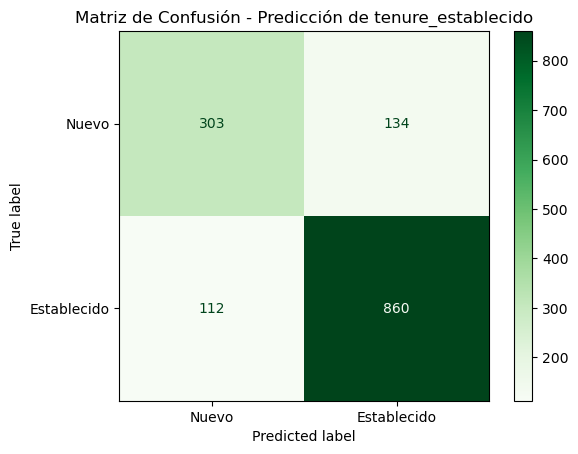

In [28]:
cm_p2 = confusion_matrix(y_test_p2, y_pred_p2)

acc_p2 = accuracy_score(y_test_p2, y_pred_p2)
prec_p2 = precision_score(y_test_p2, y_pred_p2)
rec_p2 = recall_score(y_test_p2, y_pred_p2)
f1_p2 = f1_score(y_test_p2, y_pred_p2)

print(f"Accuracy : {acc_p2:.4f}")
print(f"Precision: {prec_p2:.4f}")
print(f"Recall   : {rec_p2:.4f}")
print(f"F1-Score : {f1_p2:.4f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm_p2, display_labels=['Nuevo', 'Establecido'])
disp.plot(cmap='Greens', values_format='d')
plt.title('Matriz de Confusión - Predicción de tenure_establecido')
plt.show()

### **¿Es predecible el nuevo objetivo?**

Los resultados obtenidos indican que el nuevo target es razonablemente predecible, aunque no de forma perfecta. Sobre el conjunto de testeo, el modelo alcanzó un accuracy de 82,54 %, una precision de 86,52 %, un recall de 88,48 % y un F1-score de 87,49 %.

La matriz de confusión muestra que se clasificaron correctamente 303 clientes nuevos y 860 clientes establecidos. Sin embargo, 134 clientes nuevos fueron clasificados incorrectamente como establecidos, y 112 clientes establecidos fueron clasificados como nuevos. En total, el
modelo cometió 246 errores sobre 1409 observaciones.

Los resultados obtenidos son superiores a los que generaría un modelo que siempre predijera la clase mayoritaria (`Establecido`, que representa aproximadamente el 69 % de los casos en el conjunto de testeo). Por lo tanto, las variables utilizadas sí contienen información útil para distinguir entre clientes nuevos y establecidos, aunque la relación no es tan fuerte como para lograr una separación casi perfecta entre ambas clases.

Cabe destacar que, en una primera versión de este modelo, se había incluido `TotalCharges` entre las features, lo que arrojaba un accuracy de 98,72 %. Al analizar ese resultado, notamos que era demasiado alto para un problema de este tipo, y encontramos la causa: al acumularse mes a mes, `TotalCharges` es aproximadamente el producto de `tenure` por `MonthlyCharges`, por lo que codifica indirectamente la antigüedad del cliente — la misma variable que usamos para construir el target. Dejar esa columna en `X` constituía una forma de Data Leakage: el modelo no estaba aprendiendo un patrón real de comportamiento, sino reconstruyendo el target por otra vía. Al excluir `TotalCharges`, el accuracy bajó a 82,54 %,
un resultado más bajo pero también más creíble y representativo de la verdadera capacidad predictiva de las features restantes.

## **Resumen y conclusiones**

### **Parte I: Predicción de abandono de clientes**

Los resultados muestran que el abandono está asociado con las primeras etapas de la relación entre el cliente y la empresa. Los clientes con *menor antigüedad* y aquellos que *utilizan contratos mensuales* presentan tasas de abandono más altas. Esto sugiere que las acciones de retención podrían concentrarse especialmente en los clientes nuevos.

El modelo base presenta una capacidad aceptable para distinguir entre clientes que permanecen y clientes que abandonan. Alcanzó un accuracy de 80,55 %, una precision de 65,82 %, un recall de 55,61 % y un F1-score de 60,29 %. Aunque su accuracy supera al 73,46 % que obtendría un modelo que siempre predijera la clase mayoritaria, la diferencia no es suficiente. En particular, el recall muestra que el modelo base detecta solamente alrededor del 56 % de los clientes que efectivamente abandonan. Por eso, también es necesario considerar precision, recall y F1-score sobre la clase `Churn = Yes`.

Para mejorar la detección de clientes que abandonan, se creó un segundo modelo aplicando SMOTE únicamente sobre el conjunto de entrenamiento. Este modelo alcanzó un accuracy de 73,74 %, una precision de 50,34 %, un recall de 79,68 % y un F1-score de 61,70 %. En comparación con el modelo base, el recall aumentó de 55,61 % a 79,68 %, por lo que se detectó una proporción considerablemente mayor de los clientes que efectivamente abandonaron. La matriz de confusión muestra 298 verdaderos positivos y 76 falsos negativos.

Esta mejora en el recall produjo un costo: la precision disminuyó de 65,82 % a 50,34 % y se generaron 294 falsos positivos. Por lo tanto, concluimos que SMOTE hace que el modelo sea mas propoenso a detectar posibles bajas, pero también aumentó la cantidad de clientes clasificados como riesgosos que en realidad permanecieron. El F1-score mejoró levemente, de 60,29 % a 61,70 %, mientras que el accuracy disminuyó. Esto confirma que la elección entre ambos modelos depende del costo que la empresa asigne a los falsos positivos y a los falsos negativos.

Como mejora futura, podría evaluarse un árbol de decisión. A diferencia de la regresión logística, este modelo puede capturar relaciones no lineales e interacciones entre variables. Por ejemplo, podría identificar combinaciones de baja antigüedad, contrato mensual y cargos elevados asociadas con un mayor riesgo de abandono. Sin embargo, los árboles pueden sobreajustarse si crecen demasiado, lo cual puede reducir su rendimiento con datos nuevos. Sería necesario controlar su profundidad y otros hiperparámetros mediante validación cruzada.


### **Parte II: Predicción de clientes establecidos**

En la segunda parte se reformuló el problema utilizando una nueva variable objetivo basada en `tenure`. Esta variable asigna un 1 a los clientes establecidos, con más de 12 meses de antigüedad, y un 0 a los clientes nuevos, con una antigüedad menor o igual a 12 meses. La variable original `tenure` se excluyó de las variables predictoras para evitar una filtración directa de la respuesta (*data leakage*).

También se excluyó `TotalCharges`, ya que al acumularse mes a mes es aproximadamente el producto de `tenure` por `MonthlyCharges`, por lo que codifica indirectamente la antigüedad del cliente. Dejarla entre las features constituía una forma de *data leakage* indirecto: en
una primera versión del modelo que sí la incluía, el accuracy alcanzaba 98,72 %, un valor demasiado alto para ser un patrón de comportamiento genuino.

Se entrenó una regresión logística para predecir esta nueva variable objetivo. Sobre el conjunto de testeo, el modelo alcanzó un accuracy de 82,54 %, una precision de 86,52 %, un recall de 88,48 % y un F1-score de 87,49 %. La matriz de confusión mostró 246 errores sobre 1409 observaciones (134 clientes nuevos fueron clasificados como establecidos y 112 clientes establecidos fueron clasificados como nuevos). Estos resultados, superiores a los de un modelo naive que siempre prediga la clase mayoritaria (aproximadamente 69% de accuracy), indican que el nuevo objetivo es razonablemente predecible con las variables utilizadas, aunque no de forma perfecta.